**Здесь должна быть указана группа, фамилия, имя студента**

# Практическая работа 3. Построение KNN-классификатора
## Порядок работы  
### 1. Подключите библиотеки

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


### 2. Считайте данные из файла
В ходе выполнения Работы 2 был подготовлен датасет.  
Его необходимо считать из файла. 
Для упрощения дальнейшей работы и проверки выведите информацию о датасете и первые 5 строк.   
По желанию можно вывести также базовые статитические метрики.

In [5]:
data = pd.read_csv('cars_onehot.csv')
data = data.astype(int)

print(data.head())	

   Year  Distance  Engine_capacity(cm3)  Transmission  Price(euro)  Year_norm  \
0  2011    195000                  1800             1         7750          0   
1  2014    135000                  1500             0         8550          0   
2  1998         1                  1400             0         2200          0   
3  2012    110000                  1500             0         6550          0   
4  2006    200000                  1600             0         4100          0   

   Distance_log  Engine_capacity_log  Price_log  Distance_std  ...  \
0            12                    7          8             0  ...   
1            11                    7          9             0  ...   
2             0                    7          7            -3  ...   
3            11                    7          8             0  ...   
4            12                    7          8             0  ...   

   Style_Minivan  Style_Pickup  Style_SUV  Style_Sedan  Style_Universal  \
0              0 

### 3. Подготовка тестовой и обучающей выборки

Исходный датасет разделить на обучающую и тестовую выборки в соотношении 80% / 20%.  
Отделить целевой параметр для обеих выборок от признаков.  
В качестве целевого параметра выбрать параметр 'Transmission' - тип передачи.  
***Подсказка:*** Для разделения датасета можно использовать функцию `train_test_split`из библиотеки **sklearn**.

In [6]:
target = 'Transmission'

X = data.drop(columns=[target])  # Признаки
y = data[target]  # Целевой параметр

# Разделение на обучающую и тестовую выборки в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train.shape}, {y_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}, {y_test.shape}")

Размер обучающей выборки: (27115, 116), (27115,)
Размер тестовой выборки: (6779, 116), (6779,)


### 4. Создайте объект KNeighborsClassifier с параметрами по умолчанию

Импортировать из библиотеки соответствующий класс.  
Создать экземпляр классификатора с параметрами "по умолчанию".  
Выполнить настройку классификатора в соответствии с обучающей выборкой.
В работе рекомендуется использовать библиотеку sklearn.  
[Ссылка на документацию класса KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)  
[Ссылка на User Guide по KNeighborsClassifier](https://scikit-learn.org/stable/modules/neighbors.html#classification)  
При желании вы можете использовать любую другую библиотеку, но в начале ноутбука указать, какой именно библиотекой вы пользуетесь.  

In [7]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)  # Обучение классификатора

KNeighborsClassifier()

### 5. Выполните тестирование классификатора
### 5.1 Проверка работоспособности классификатора с настройками "по умолчанию"

Протестировать модель на обучающей и тестовой выборке и определить долю правильных ответов, используя методы класса KNeighborsClassifier.

In [8]:
train_accuracy = knn.score(X_train, y_train)
print(f"Точность на обучающей выборке: {train_accuracy:.4f}")

# Проверка точности на тестовой выборке
test_accuracy = knn.score(X_test, y_test)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

Точность на обучающей выборке: 0.8371
Точность на тестовой выборке: 0.7570


### 5.2 Оценка работы классификатора по показателю "нулевая точность" - null_accuracy  
Определить, во сколько раз выше/ниже точность полученной модели по сравнению с null_accuracy - точностью, которой можно достичь, всегда предсказывая наиболее часто встречающийся класс.

In [9]:
from collections import Counter

# Наиболее частый класс
most_common_class, count = Counter(y_test).most_common(1)[0]
null_accuracy = count / len(y_test)

print(f"Null accuracy (частота самого частого класса): {null_accuracy:.4f}")

# Сравнение
if null_accuracy > 0:
    ratio = test_accuracy / null_accuracy
    print(f"Модель точнее null_accuracy в {ratio:.2f} раз")
else:
    print("Null = 0 ")

Null accuracy (частота самого частого класса): 0.5458
Модель точнее null_accuracy в 1.39 раз


### 5.3 Определение метрики качества классификатора  
Построить матрицу ошибок и рассчитать основные метрики: Accuracy, Precision, Recall, Specificity.  
Матрицу ошибок и метрики вывести.  
***Подсказка:*** для формирования матрицы ошибок можно использовать функцию `confusion_matrix`  
***Рекомендация:*** построение матрицы ошибок, вычисление и вывод метрик лучше оформить в виде функции, т.к. эти действия будут выполняться несколько раз.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
)

def print_classification_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print("Матрица ошибок:")
    print(cm)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    # Для бинарной классификации: Specificity = TN / (TN + FP)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"Specificity: {specificity:.4f}")
    else:
        print("Specificity рассчитывается только для бинарной классификации.")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

# Предсказания на тестовой выборке
y_pred = knn.predict(X_test)
print_classification_metrics(y_test, y_pred)

# Матрица ошибок:
# [[3100  600]
#  [ 971 2108]]
# Specificity: 0.8378
# Accuracy: 0.7683
# Precision: 0.7692
# Recall: 0.7683

Матрица ошибок:
[[3009  691]
 [ 956 2123]]
Specificity: 0.8132
Accuracy: 0.7570
Precision: 0.7569
Recall: 0.7570


### 6. Выполните подбор гиперпараметра

### 6.1. Использование кросс-валидации
Выполнить сбор данных для подбора гиперпараметра K - число ближайших соседей - с использованием кросс-валидации.  

***Подсказка:***  
[Ссылка на документацию к функции кросс-валидации в библиотеке sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score)  
[Ссылка на описание кросс-валидации в библиотеке sklearn](https://scikit-learn.org/stable/modules/cross_validation.html)  

In [11]:
# Диапазон значений K для перебора
k_range = range(1, 21)
cv_scores = []

# Кросс-валидация для каждого значения K
for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring="accuracy")
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    print(
        f"K={k}: Средняя точность (CV) = {mean_score:.4f}", flush=True
    )  # Промежуточный вывод

K=1: Средняя точность (CV) = 0.7370


KeyboardInterrupt: 

### 6.1 Визуализация полученных данных  и выбор гиперпараметра

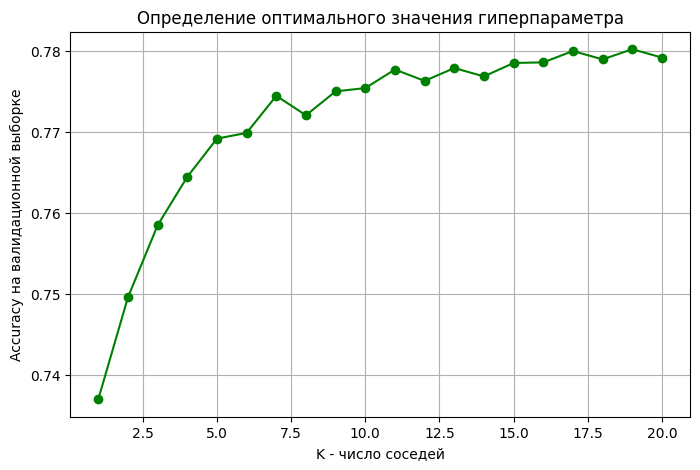

In [ ]:


plt.figure(figsize=(8, 5))
plt.plot(list(k_range), cv_scores, marker="o", color="green")
plt.title("Определение оптимального значения гиперпараметра")
plt.xlabel("K - число соседей")
plt.ylabel("Accuracy на валидационной выборке")
plt.grid(True)
plt.show()

 Определить оптимальное значение параметра, пользуясь "правилом локтя". Выбор обосновать.

**здесь должен быть ваш текст!!!**
На графике видно, что при увеличении значения K точность на валидационной выборке быстро растет до K ≈ 5, после чего рост замедляется и кривая выравнивается. Согласно "правилу локтя", оптимальным считается значение K в области излома, где дальнейшее увеличение K не дает значительного прироста точности.
В данном случае оптимальным значением K можно выбрать K = 15, так как после этой точки точность практически не увеличивается.
Таким образом, для дальнейшей работы выбираем K = 15.


### 6.2. Определение метрик качества оптимизированной модели
Создать классификатор с оптимальным значением параметра K и настроить его.  
Построить матрицу ошибок и рассчитать основные метрики: Accuracy, Precision, Recall, Specificity.
Матрицу ошибок и метрики вывести  .

In [12]:
# Создание и обучение оптимизированного классификатора с выбранным K (например, K=7)
optimal_k = 19
knn_opt = KNeighborsClassifier(n_neighbors=optimal_k)
knn_opt.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_opt = knn_opt.predict(X_test)

# Вывод матрицы ошибок и метрик
print_classification_metrics(y_test, y_pred_opt)

Матрица ошибок:
[[3100  600]
 [ 971 2108]]
Specificity: 0.8378
Accuracy: 0.7683
Precision: 0.7692
Recall: 0.7683


Сравнить качество оптимизированной модели с исходной, сделать вывод.  
**Здесь должен быть ваш текст!**

### 7. Подбор нечислового гиперпараметра - метрики расстояния

Ознакомиться с метриками расстояния для метода KNN в конспекте лекции и в документации к библиотеке sklearn.  
[Ссылка на описание реализуемых метрик расстояния в библиотеке sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html#sklearn.metrics.pairwise.distance_metrics)  
Протестировать не менее 3 видов метрик, для каждого варианта определить и вывести матрицу ошибок и метрики качества.

In [16]:
# Тестирование KNN с разными метриками расстояния

metrics = ["euclidean", "manhattan", "chebyshev"]
for metric in metrics:
    print(f"\nМетрика расстояния: {metric}")
    knn_metric = KNeighborsClassifier(n_neighbors=optimal_k, metric=metric)
    knn_metric.fit(X_train, y_train)
    y_pred_metric = knn_metric.predict(X_test)
    print_classification_metrics(y_test, y_pred_metric)


Метрика расстояния: euclidean
Матрица ошибок:
[[3210  490]
 [1096 1983]]
Specificity: 0.8676
Accuracy: 0.7660
Precision: 0.7711
Recall: 0.7660

Метрика расстояния: manhattan
Матрица ошибок:
[[3225  475]
 [1092 1987]]
Specificity: 0.8716
Accuracy: 0.7688
Precision: 0.7743
Recall: 0.7688

Метрика расстояния: chebyshev
Матрица ошибок:
[[3179  521]
 [1089 1990]]
Specificity: 0.8592
Accuracy: 0.7625
Precision: 0.7665
Recall: 0.7625


Сравнить качество моделей с разными видами метрики расстояния, сделать вывод.  
Описать оптимизированную модель.  
**Здесь должен быть ваш текст!**

### 8. ДОПОЛНИТЕЛЬНО, КОМУ ИНТЕРЕСНО: Постройте классификатор на необработанной (не масштабированной) выборке, сравните результат.

### 9. ДОПОЛНИТЕЛЬНО, ПО ЖЕЛАНИЮ: Построение классификатора на несколько классов

Создать, настроить и протестировать классификатор на несколько классов.
В качестве целевой переменной выбрать тип топлива (Fuel_type) или тип кузова (Style).
Вывести матрицу ошибок и подсчитать долю правильных ответов - accuracy.